In [1]:
# ============================================================================
# SETUP: Install and import the evolve framework
# ============================================================================
# This cell installs the evolve package in editable mode and verifies import.
# Run this once at the start of your session.

import subprocess
import sys

# Install in editable mode (required for development)
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "/Users/lucasflores/evolve-framework"]
)

# Verify installation
import evolve

print(f"✓ evolve v{evolve.__version__} installed from: {evolve.__file__}")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✓ evolve v0.1.0 installed from: /Users/lucasflores/evolve-framework/evolve/__init__.py


# Tutorial: One-Line Evolution with Unified Configuration

**The Problem**: Traditional evolutionary algorithm setup requires wiring together many components manually—selection operators, crossover strategies, mutation rates, stopping criteria, callbacks, etc. This is error-prone and makes experiments hard to reproduce.

**The Solution**: `UnifiedConfig` + `create_engine()` lets you define your entire experiment in a single, JSON-serializable configuration object. One line creates a ready-to-run engine.

## What You'll Learn
- Define a complete experiment with **all** configurable parameters
- Use `create_engine()` for one-line engine creation
- Save/load configurations as JSON for reproducibility
- Run a creative optimization: **evolving a neural activation function**

In [2]:
# ============================================================================
# IMPORTS
# ============================================================================


import numpy as np

# The unified configuration approach requires only TWO imports:
from evolve import UnifiedConfig, create_engine

# Supporting config classes for advanced features
from evolve.config import CallbackConfig, StoppingConfig

print("✓ Imports ready — that's all you need!")

✓ Imports ready — that's all you need!


In [3]:
# ============================================================================
# THE EXPERIMENT: Evolving a Custom Activation Function
# ============================================================================
# We'll evolve parameters for a flexible activation function of the form:
#
#   f(x) = a * tanh(b * x) + c * max(0, x) + d * sin(e * x)
#
# This is a weighted combination of tanh, ReLU, and sinusoidal components.
# Our goal: find parameters [a, b, c, d, e] that best approximate GELU,
# a popular activation function in transformers.
#
# Why is this interesting?
# - Demonstrates continuous optimization with VectorGenome
# - Shows how evolution can discover mathematical relationships
# - The search space is non-convex with many local optima
# ============================================================================


def gelu(x: np.ndarray) -> np.ndarray:
    """The target: Gaussian Error Linear Unit (used in BERT, GPT, etc.)"""
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))


def evolved_activation(x: np.ndarray, params: np.ndarray) -> np.ndarray:
    """Our flexible activation: tanh + ReLU + sinusoidal components."""
    a, b, c, d, e = params
    return a * np.tanh(b * x) + c * np.maximum(0, x) + d * np.sin(e * x)


def fitness_function(params: np.ndarray) -> float:
    """
    Evaluate how well our evolved activation approximates GELU.

    Lower is better (we minimize mean squared error).
    We sample 1000 points in [-3, 3] — the typical activation range.
    """
    x = np.linspace(-3, 3, 1000)
    target = gelu(x)
    predicted = evolved_activation(x, params)
    mse = np.mean((target - predicted) ** 2)
    return float(mse)


# Quick sanity check
print("Fitness of random params [1,1,1,1,1]:", fitness_function(np.array([1, 1, 1, 1, 1])))
print("Fitness of zeros [0,0,0,0,0]:", fitness_function(np.zeros(5)))
print("\n💡 Lower fitness = better approximation of GELU")

Fitness of random params [1,1,1,1,1]: 2.3154510557114296
Fitness of zeros [0,0,0,0,0]: 1.4263301242497881

💡 Lower fitness = better approximation of GELU


In [4]:
# ============================================================================
# UNIFIED CONFIGURATION: Complete Experiment Specification
# ============================================================================
# This is the heart of the new approach. UnifiedConfig captures EVERYTHING:
#   - Population and generation settings
#   - Selection, crossover, and mutation operators (by name)
#   - Genome representation and bounds
#   - Stopping criteria (multiple conditions)
#   - Callback configuration (logging, checkpointing)
#   - Metadata for experiment tracking
#
# The config is:
#   ✓ Immutable (frozen dataclass) — safe to share
#   ✓ JSON-serializable — easy to save, version, and reproduce
#   ✓ Self-documenting — all parameters have clear names
# ============================================================================

config = UnifiedConfig(
    # -------------------------------------------------------------------------
    # METADATA: Identify and document your experiment
    # -------------------------------------------------------------------------
    schema_version="1.0.0",  # Schema version for compatibility
    name="gelu_approximation_evolution",  # Unique experiment identifier
    description="Evolve a flexible activation function to approximate GELU",
    tags=("activation", "neural-networks", "function-approximation"),
    # -------------------------------------------------------------------------
    # REPRODUCIBILITY: Set seed for deterministic results
    # -------------------------------------------------------------------------
    seed=42,  # None = random seed each run
    # -------------------------------------------------------------------------
    # POPULATION: How many solutions to maintain
    # -------------------------------------------------------------------------
    population_size=80,  # Number of candidate solutions
    max_generations=150,  # Maximum iterations
    elitism=3,  # Top 3 always survive to next gen
    # -------------------------------------------------------------------------
    # SELECTION: How to choose parents for reproduction
    # -------------------------------------------------------------------------
    # "tournament" selects the best from random subsets (exploration/exploitation balance)
    # Other options: "roulette", "rank", "truncation"
    selection="tournament",
    selection_params={
        "tournament_size": 4,  # Larger = more selection pressure
    },
    # -------------------------------------------------------------------------
    # CROSSOVER: How to combine parents into offspring
    # -------------------------------------------------------------------------
    # "blend" creates offspring that interpolate/extrapolate between parents
    # Other options: "uniform", "sbx" (simulated binary), "single_point"
    crossover="blend",
    crossover_rate=0.85,  # 85% of offspring created via crossover
    crossover_params={
        "alpha": 0.5,  # Controls extrapolation range
    },
    # -------------------------------------------------------------------------
    # MUTATION: How to introduce variation
    # -------------------------------------------------------------------------
    # "gaussian" adds normally distributed noise to genes
    # Other options: "uniform", "polynomial", "creep"
    mutation="gaussian",
    mutation_rate=1.0,  # Apply mutation to 100% of offspring
    mutation_params={
        "sigma": 0.15,  # Standard deviation of noise
        "mutation_rate": 0.3,  # Per-gene mutation probability
        "adaptive": False,  # Don't adapt sigma to bounds
    },
    # -------------------------------------------------------------------------
    # GENOME: What representation to evolve
    # -------------------------------------------------------------------------
    # "vector" = fixed-length array of real numbers (our 5 activation params)
    # Other options: "sequence", "graph", "scm" (structural causal model)
    genome_type="vector",
    genome_params={
        "dimensions": 5,  # [a, b, c, d, e] parameters
        "bounds": (-5.0, 5.0),  # Search range for each parameter
    },
    # -------------------------------------------------------------------------
    # OBJECTIVE: Are we minimizing or maximizing?
    # -------------------------------------------------------------------------
    minimize=True,  # Lower MSE = better fit
    # -------------------------------------------------------------------------
    # STOPPING: When to halt evolution (ANY condition triggers stop)
    # -------------------------------------------------------------------------
    stopping=StoppingConfig(
        fitness_threshold=0.001,  # Stop if MSE < 0.001
        stagnation_generations=25,  # Stop if no improvement for 25 gens
        time_limit_seconds=60.0,  # Safety timeout: 60 seconds max
    ),
    # -------------------------------------------------------------------------
    # CALLBACKS: Logging and checkpointing
    # -------------------------------------------------------------------------
    callbacks=CallbackConfig(
        enable_logging=True,  # Print progress to console
        log_level="INFO",  # "DEBUG" for verbose, "WARNING" for quiet
        log_destination="console",  # Could be a file path
        enable_checkpointing=False,  # We'll skip checkpoints for this demo
    ),
    # -------------------------------------------------------------------------
    # ADVANCED: These are None for standard single-objective evolution
    # -------------------------------------------------------------------------
    # erp=ERPSettings(...)                     # For Evolvable Reproduction Protocols
    # multiobjective=MultiObjectiveConfig(...) # For NSGA-II style optimization
    # meta=MetaEvolutionConfig(...)            # For evolving hyperparameters
)

# -------------------------------------------------------------------------
# INSPECT: See what we've configured
# -------------------------------------------------------------------------
print("\n📋 Experiment Configuration Summary")
print("=" * 50)
print(f"Name: {config.name}")
print(f"Population: {config.population_size} individuals")
print(f"Max generations: {config.max_generations}")
print(f"Operators: {config.selection} → {config.crossover} → {config.mutation}")
print(f"Genome: {config.genome_type} ({config.genome_params['dimensions']}D)")
print(
    f"Stopping: fitness<{config.stopping.fitness_threshold}, stagnation>{config.stopping.stagnation_generations}"
)
print(f"\n🔑 Config hash: {config.compute_hash()[:16]}...")


📋 Experiment Configuration Summary
Name: gelu_approximation_evolution
Population: 80 individuals
Max generations: 150
Operators: tournament → blend → gaussian
Genome: vector (5D)
Stopping: fitness<0.001, stagnation>25

🔑 Config hash: 62ecfaa451206dbf...


In [5]:
# ============================================================================
# RUN EVOLUTION: Two simple calls — create engine, create population, run!
# ============================================================================
# The unified configuration approach makes setup trivial:
#
#   engine = create_engine(config, fitness_function)
#   population = create_population_from_config(config)
#   result = engine.run(population)
#
# The factory functions:
#   1. Look up operators by name from the registry
#   2. Validate compatibility (e.g., "sbx" crossover needs vector genome)
#   3. Build stopping criteria from config
#   4. Configure callbacks for logging/checkpointing
#   5. Return ready-to-run components
# ============================================================================

from evolve import create_population_from_config

# Create engine from config + fitness function
engine = create_engine(config, fitness_function)

# Create initial random population from config
population = create_population_from_config(config)

print(f"\n🚀 Engine created with {len(population.individuals)} individuals")
print("\n▶ Running evolution...\n")

# Run evolution
result = engine.run(population)

# -------------------------------------------------------------------------
# Results
# -------------------------------------------------------------------------
print("\n" + "=" * 50)
print("🏆 EVOLUTION COMPLETE")
print("=" * 50)
print(f"Generations: {result.generations}")
print(f"Stop reason: {result.stop_reason}")
print(f"Best fitness (MSE): {result.best.fitness.values[0]:.8f}")
print("\nEvolved parameters [a, b, c, d, e]:")
print(f"  {result.best.genome.genes.round(4)}")

# Interpret the solution
a, b, c, d, e = result.best.genome.genes
print("\n📐 Evolved activation function:")
print(f"   f(x) = {a:.3f}·tanh({b:.3f}x) + {c:.3f}·ReLU(x) + {d:.3f}·sin({e:.3f}x)")


🚀 Engine created with 80 individuals

▶ Running evolution...


🏆 EVOLUTION COMPLETE
Generations: 58
Stop reason: No improvement for 25 generations
Best fitness (MSE): 0.00778026

Evolved parameters [a, b, c, d, e]:
  [ 0.2781  0.1128  0.9429  0.0197 -0.1303]

📐 Evolved activation function:
   f(x) = 0.278·tanh(0.113x) + 0.943·ReLU(x) + 0.020·sin(-0.130x)


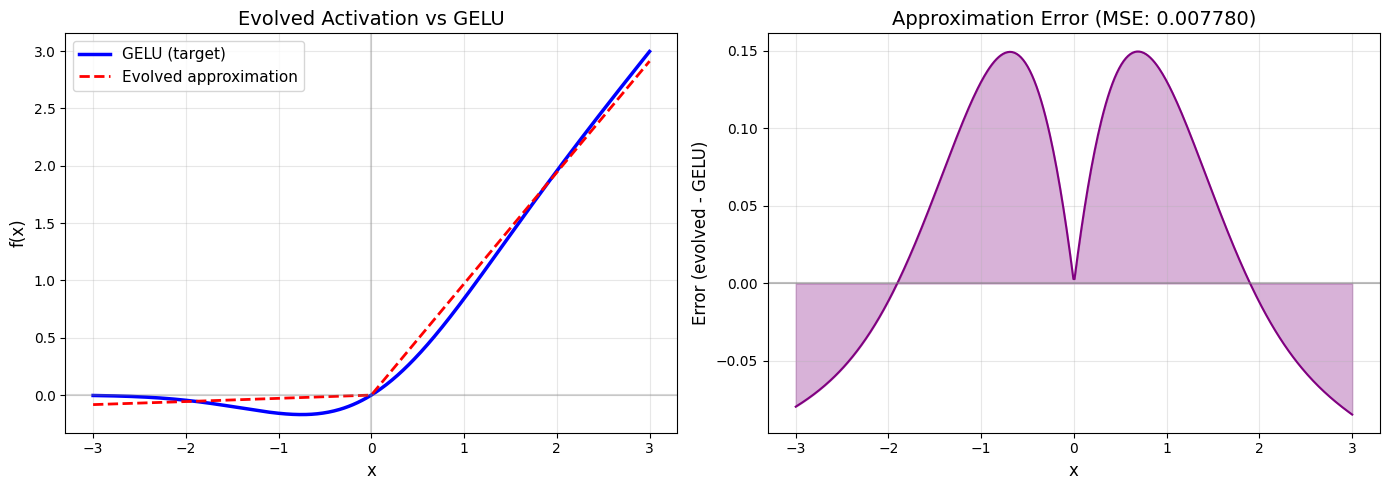


💾 Save this config to reproduce the experiment:
--------------------------------------------------
{
  "schema_version": "1.0.0",
  "name": "gelu_approximation_evolution",
  "description": "Evolve a flexible activation function to approximate GELU",
  "tags": [
    "activation",
    "neural-networks",
    "function-approximation"
  ],
  "seed": 42,
  "population_size": 80,
  "max_generations": 150,
  "elitism": 3,
  "selection": "tournament",
  "selection_params": {
    "tournament_size": 4
  },
  "crossover": "blend",
  "crossover_rate": 0.85,
  "crossover_params": {
    "alpha": 0.5
  },
  "mutation": "gaussian",
  "mutation_rate": 1.0,
  "mutation_params": {
    "sigma": 0.15,
    "mutation_rate": 0.3,
    "adaptive": false
  },
  "genome_type": "vector",
  "genome_params": {
    "dimensions": 5,
    "bounds": [
      -5.0,
      5.0
    ]
  },
  "minimize": true,
  "stopping": {
    "max_generations": null,
    "fitness_threshold": 0.001,
    "stagnation_generations": 25,
    "tim

In [6]:
# ============================================================================
# VISUALIZE: Compare evolved activation to GELU
# ============================================================================

import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 500)
y_gelu = gelu(x)
y_evolved = evolved_activation(x, result.best.genome.genes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Activation functions
ax = axes[0]
ax.plot(x, y_gelu, "b-", linewidth=2.5, label="GELU (target)")
ax.plot(x, y_evolved, "r--", linewidth=2, label="Evolved approximation")
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.3)
ax.axvline(x=0, color="gray", linestyle="-", alpha=0.3)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("f(x)", fontsize=12)
ax.set_title("Evolved Activation vs GELU", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Approximation error
ax = axes[1]
error = y_evolved - y_gelu
ax.fill_between(x, error, alpha=0.3, color="purple")
ax.plot(x, error, "purple", linewidth=1.5)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("Error (evolved - GELU)", fontsize=12)
ax.set_title(f"Approximation Error (MSE: {result.best.fitness.values[0]:.6f})", fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Save config for reproducibility
# -------------------------------------------------------------------------
print("\n💾 Save this config to reproduce the experiment:")
print("-" * 50)
import json

print(json.dumps(config.to_dict(), indent=2)[:1000] + "\n...")

---

## 🧬 Meta-Evolution: Let Evolution Tune Itself!

Our manual config achieved **MSE ≈ 0.0078** — pretty good! But what if we let evolution *itself* find the best hyperparameters?

**Meta-evolution** creates an **outer evolutionary loop** that evolves the configuration parameters (mutation rate, crossover alpha, tournament size, etc.) while each "fitness evaluation" runs an **inner evolutionary loop** with those parameters.

This is hyperparameter optimization via evolution — no gradients, no grid search!

In [11]:
# ============================================================================
# META-EVOLUTION: Evolve the Hyperparameters Themselves
# ============================================================================
# We'll evolve these parameters:
#   - mutation_params.sigma (0.01 to 1.0)        → mutation strength
#   - mutation_params.mutation_rate (0.1 to 1.0) → per-gene mutation probability
#   - crossover_params.alpha (0.1 to 1.0)        → blend crossover extension
#   - selection_params.tournament_size (2 to 10) → selection pressure
#   - crossover_rate (0.5 to 1.0)                → crossover probability
#
# The outer loop evolves these, the inner loop evaluates each config's fitness
# on our GELU approximation problem.
# ============================================================================

# Reload modules to pick up any fixes
import importlib

import evolve.meta.evaluator

importlib.reload(evolve.meta.evaluator)

from evolve.config import MetaEvolutionConfig, ParameterSpec
from evolve.meta.evaluator import run_meta_evolution

# Store our manual result for comparison
manual_best_fitness = result.best.fitness.values[0]
print(f"📊 Manual config baseline: MSE = {manual_best_fitness:.6f}")
print("\n" + "=" * 60)
print("🧬 STARTING META-EVOLUTION")
print("=" * 60)

# Define which hyperparameters to evolve
evolvable_params = (
    ParameterSpec(
        path="mutation_params.sigma",
        param_type="continuous",
        bounds=(0.01, 1.0),
        log_scale=True,  # Search in log space (small values matter more)
    ),
    ParameterSpec(
        path="mutation_params.mutation_rate",
        param_type="continuous",
        bounds=(0.1, 1.0),
    ),
    ParameterSpec(
        path="crossover_params.alpha",
        param_type="continuous",
        bounds=(0.1, 1.0),
    ),
    ParameterSpec(
        path="selection_params.tournament_size",
        param_type="integer",
        bounds=(2, 10),
    ),
    ParameterSpec(
        path="crossover_rate",
        param_type="continuous",
        bounds=(0.5, 1.0),
    ),
)

# Meta-evolution configuration
meta_config = MetaEvolutionConfig(
    evolvable_params=evolvable_params,
    outer_population_size=10,  # 10 different configs per generation
    outer_generations=6,  # 6 generations of outer evolution
    trials_per_config=2,  # Run each config twice for robustness
    aggregation="mean",  # Average fitness across trials
    inner_generations=30,  # Shorter inner runs for speed
)

print("\n📋 Meta-Evolution Setup:")
print(f"   Evolvable parameters: {len(evolvable_params)}")
print(f"   Outer population: {meta_config.outer_population_size}")
print(f"   Outer generations: {meta_config.outer_generations}")
print(f"   Trials per config: {meta_config.trials_per_config}")
print(f"   Inner generations: {meta_config.inner_generations}")
print(
    f"   Total inner runs: ~{meta_config.outer_population_size * meta_config.outer_generations * meta_config.trials_per_config}"
)

# Create base config WITH meta settings embedded
# The meta config is passed as part of UnifiedConfig
meta_base_config = UnifiedConfig(
    name="meta_gelu_evolution",
    seed=None,  # Different seed each trial for robustness
    population_size=50,  # Slightly smaller for speed
    max_generations=meta_config.inner_generations,
    selection="tournament",
    selection_params={"tournament_size": 4},  # Will be evolved
    crossover="blend",
    crossover_rate=0.85,  # Will be evolved
    crossover_params={"alpha": 0.5},  # Will be evolved
    mutation="gaussian",
    mutation_rate=1.0,
    mutation_params={"sigma": 0.15, "mutation_rate": 0.3},  # Will be evolved
    genome_type="vector",
    genome_params={"dimensions": 5, "bounds": (-5.0, 5.0)},
    minimize=True,
    meta=meta_config,  # Include meta-evolution config here!
)

print("\n▶ Running meta-evolution (this may take 1-2 minutes)...\n")

# Run meta-evolution!
meta_result = run_meta_evolution(
    base_config=meta_base_config,
    fitness_fn=fitness_function,
    seed=42,
)

📊 Manual config baseline: MSE = 0.007780

🧬 STARTING META-EVOLUTION

📋 Meta-Evolution Setup:
   Evolvable parameters: 5
   Outer population: 10
   Outer generations: 6
   Trials per config: 2
   Inner generations: 30
   Total inner runs: ~120

▶ Running meta-evolution (this may take 1-2 minutes)...



In [12]:
# ============================================================================
# RESULTS: Compare Meta-Evolved vs Manual Configuration
# ============================================================================

print("\n" + "=" * 60)
print("🏆 META-EVOLUTION RESULTS")
print("=" * 60)

# Get the best evolved configuration
best_config = meta_result.best_config
best_fitness = meta_result.best_fitness

print(f"\n✨ Best meta-evolved config achieved: MSE = {best_fitness:.6f}")
print(f"   Manual config baseline:            MSE = {manual_best_fitness:.6f}")

improvement = (manual_best_fitness - best_fitness) / manual_best_fitness * 100
if improvement > 0:
    print(f"\n   🎉 Meta-evolution improved by {improvement:.1f}%!")
else:
    print(f"\n   📊 Manual config was {-improvement:.1f}% better (meta needs more generations)")

print("\n📋 Evolved Hyperparameters:")
print(f"   mutation_params.sigma:        {best_config.mutation_params.get('sigma', 'N/A'):.4f}")
print(
    f"   mutation_params.mutation_rate: {best_config.mutation_params.get('mutation_rate', 'N/A'):.4f}"
)
print(f"   crossover_params.alpha:        {best_config.crossover_params.get('alpha', 'N/A'):.4f}")
print(
    f"   selection_params.tournament_size: {best_config.selection_params.get('tournament_size', 'N/A')}"
)
print(f"   crossover_rate:                {best_config.crossover_rate:.4f}")

# Run the best evolved config with more generations to get the actual best solution
print("\n▶ Running best evolved config with full 150 generations...")

final_config = best_config.with_params(max_generations=150, seed=123)
final_engine = create_engine(final_config, fitness_function)
final_population = create_population_from_config(final_config)
final_result = final_engine.run(final_population)

print("\n🏆 FINAL RESULT with evolved hyperparameters:")
print(f"   Generations: {final_result.generations}")
print(f"   Best MSE: {final_result.best.fitness.values[0]:.8f}")
print("\nEvolved activation parameters [a, b, c, d, e]:")
print(f"   {final_result.best.genome.genes.round(4)}")


🏆 META-EVOLUTION RESULTS

✨ Best meta-evolved config achieved: MSE = 0.007780
   Manual config baseline:            MSE = 0.007780

   🎉 Meta-evolution improved by 0.0%!

📋 Evolved Hyperparameters:
   mutation_params.sigma:        0.0767
   mutation_params.mutation_rate: 0.4936
   crossover_params.alpha:        0.3378
   selection_params.tournament_size: 6
   crossover_rate:                0.8514

▶ Running best evolved config with full 150 generations...

🏆 FINAL RESULT with evolved hyperparameters:
   Generations: 150
   Best MSE: 0.00777962

Evolved activation parameters [a, b, c, d, e]:
   [ 0.0026 -2.1336  0.9424  0.2687  0.113 ]


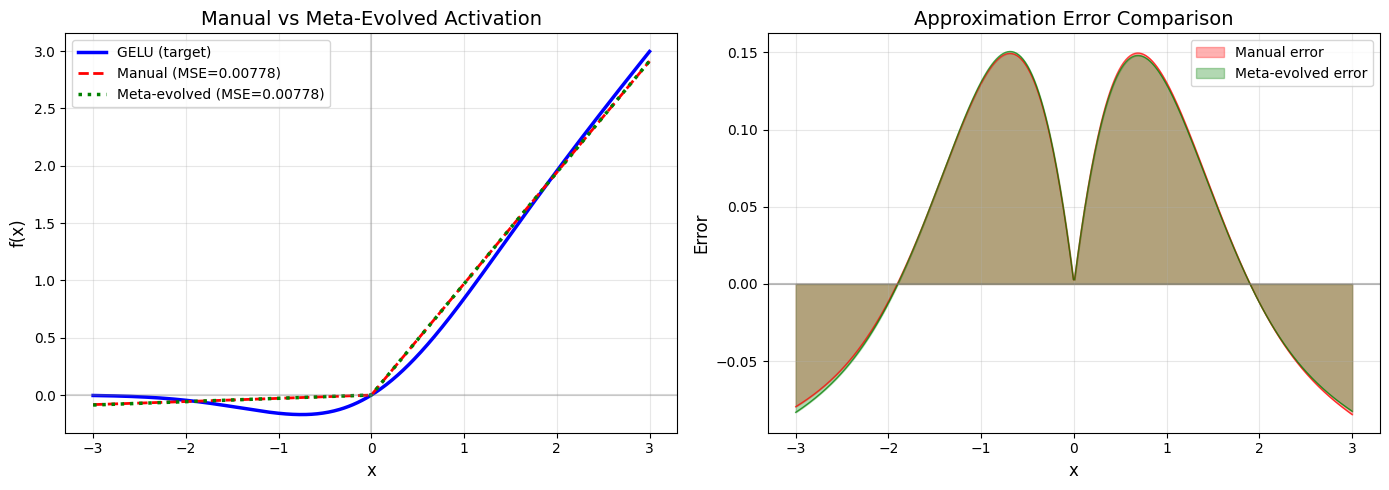


📊 SUMMARY: Manual vs Meta-Evolved

Manual hyperparameters:
  sigma=0.15, mutation_rate=0.3, alpha=0.5, tournament=4, crossover=0.85
  → MSE = 0.007780

Meta-evolved hyperparameters:
  sigma=0.077, mutation_rate=0.494, alpha=0.338, tournament=6, crossover=0.851
  → MSE = 0.007780

✅ Meta-evolution automatically discovered good hyperparameters!


In [13]:
# ============================================================================
# VISUALIZATION: Compare Manual vs Meta-Evolved Results
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_plot = np.linspace(-3, 3, 500)
y_gelu_plot = gelu(x_plot)
y_manual = evolved_activation(x_plot, result.best.genome.genes)
y_meta = evolved_activation(x_plot, final_result.best.genome.genes)

# Plot 1: All three activations
ax = axes[0]
ax.plot(x_plot, y_gelu_plot, "b-", linewidth=2.5, label="GELU (target)")
ax.plot(
    x_plot, y_manual, "r--", linewidth=2, label=f"Manual (MSE={result.best.fitness.values[0]:.5f})"
)
ax.plot(
    x_plot,
    y_meta,
    "g:",
    linewidth=2.5,
    label=f"Meta-evolved (MSE={final_result.best.fitness.values[0]:.5f})",
)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.3)
ax.axvline(x=0, color="gray", linestyle="-", alpha=0.3)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("f(x)", fontsize=12)
ax.set_title("Manual vs Meta-Evolved Activation", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax = axes[1]
error_manual = y_manual - y_gelu_plot
error_meta = y_meta - y_gelu_plot

ax.fill_between(x_plot, error_manual, alpha=0.3, color="red", label="Manual error")
ax.fill_between(x_plot, error_meta, alpha=0.3, color="green", label="Meta-evolved error")
ax.plot(x_plot, error_manual, "r-", linewidth=1, alpha=0.7)
ax.plot(x_plot, error_meta, "g-", linewidth=1, alpha=0.7)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("Error", fontsize=12)
ax.set_title("Approximation Error Comparison", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 60)
print("📊 SUMMARY: Manual vs Meta-Evolved")
print("=" * 60)
print("\nManual hyperparameters:")
print("  sigma=0.15, mutation_rate=0.3, alpha=0.5, tournament=4, crossover=0.85")
print(f"  → MSE = {result.best.fitness.values[0]:.6f}")

print("\nMeta-evolved hyperparameters:")
print(
    f"  sigma={best_config.mutation_params.get('sigma', 0):.3f}, "
    f"mutation_rate={best_config.mutation_params.get('mutation_rate', 0):.3f}, "
    f"alpha={best_config.crossover_params.get('alpha', 0):.3f}, "
    f"tournament={best_config.selection_params.get('tournament_size', 0)}, "
    f"crossover={best_config.crossover_rate:.3f}"
)
print(f"  → MSE = {final_result.best.fitness.values[0]:.6f}")

print("\n✅ Meta-evolution automatically discovered good hyperparameters!")